In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from reservoirpy.datasets import narma
from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse
from Reservoirs.LangKobayashi import expand_virtual_nodes, simulate_lk, simulate_lk_mini, extract_R_from_E, intensities_after_theta_times, charge_at_theta_intervals

In [2]:
#commonly tuned paramameters
L = 530
N = 50
eta = 0.01 #input strength
TLk = 150
kappa = 0.1 #feedback 
ridge_alpha = 1e-6
washout = 30
order = 10
dt = 0.1
p= 0.05
#p = 0.05 #normalised injection current/pump rate

alpha = 0 #linewidth enhancemenet factor
phi = 0 #phase shift


xi = 0 #for now, this is time dependant and represents Gaussian noise.
D_noise = 10**-7*0

task_seed = 0
mask_seed = 42


#g = 1.0
split = 0.8

theta = 22
tau_factor = 1.41 #as per the Kathy Ludge paper.
 
TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)

TDMParams(N=50, theta=22, dt=0.1, T=1100, tau=1551.0, Nd_loop=11000, Nd_delay=15510, tap_stride=220)


In [3]:
u_full, y_full = narma(n_timesteps=L, order= order,a1=0.3, a2=0.05, b=1.5, c=0.1, seed=task_seed)

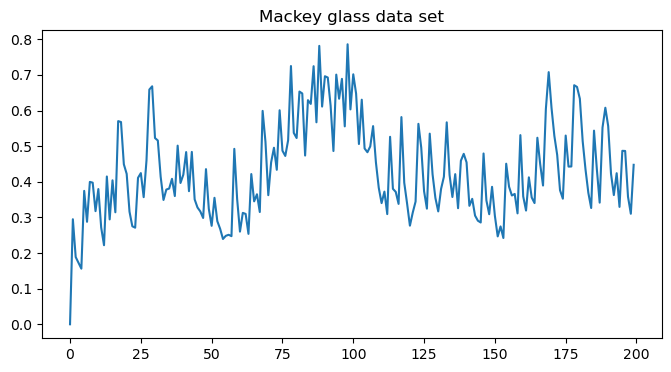

In [4]:
plt.figure(figsize=(8,4))
plt.plot(y_full[:200])
plt.title("Mackey glass data set")
plt.show()

-for the y=sin(2*pi*x), using input x, to predict output y. 
-for Mnist using X matrix(each image flattened to 1d array so that is its a row in the x matrix) and y (each row being a one hot encoded label). 
 

In [5]:
u_full = u_full[order:].ravel()   # align with y_full
y_full = y_full.ravel()

In [6]:
x_norm, mask, V = build_masked_input(u_full, N=N, rng=mask_seed)
tap_stride = TDM_parameters.tap_stride  
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau

Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  
#E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=TLk, E0=1e-3+0j, n0=0.0)
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=TLk, E0=1e-3+0j, n0=0.0)

In [7]:
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop, washout_cycles=washout)

In [8]:
y_target = y_full[washout:]
s = split_states_targets(R, y_target, split=split)

print(R.shape)
print(y_target.shape)

#model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
model = fit_ridge_readout(s.R_train, s.y_train, alpha= ridge_alpha, fit_intercept=True) # trying this to see if fit intercpet true improves performance
y_pred = predict_readout(model, s.R_test)


(500, 50)
(500,)


MSE: 0.0009841141084712117
NRMSE: 0.32574793891924275


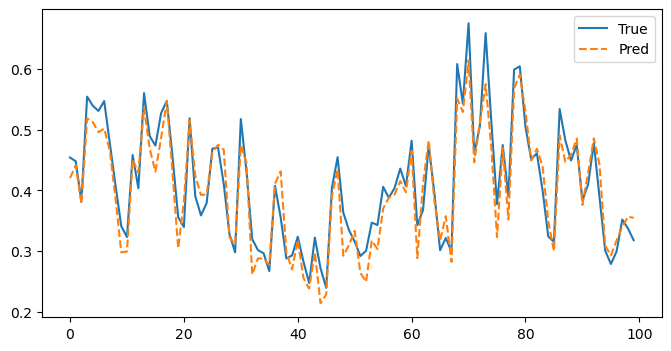

In [9]:
print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(s.y_test, label="True")
plt.plot(y_pred, "--", label="Pred")
#plt.title("eta=0.01 K=0.005 Tlk=10 a_ridge=0*e^-4. TEST DATA")
plt.legend()
plt.show()

In [10]:
R.shape
#y_target.shape 

(500, 50)